In [ ]:
# Import Libraries :-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# File Upload :-
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [ ]:
# Read Dataset :-
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

In [ ]:
# View Data :-
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Convert TotalCharges to Numeric :-
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.shape

(7043, 21)

In [ ]:
# Handle Missing Values :-
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
# Summary Statistics :-
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# Categorical Summary :-
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


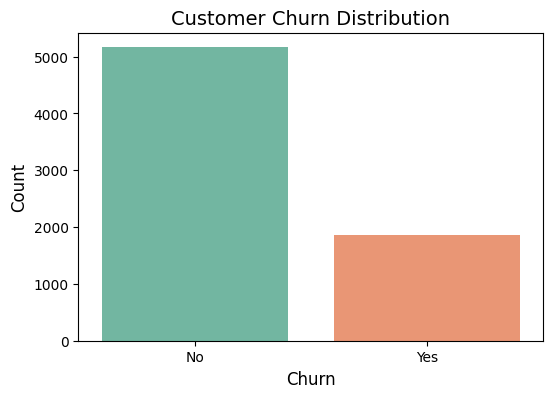

In [ ]:
# Churn Distribution (Most Important Graph) :-
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Churn', hue='Churn', data=df, palette='Set2', legend=False)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

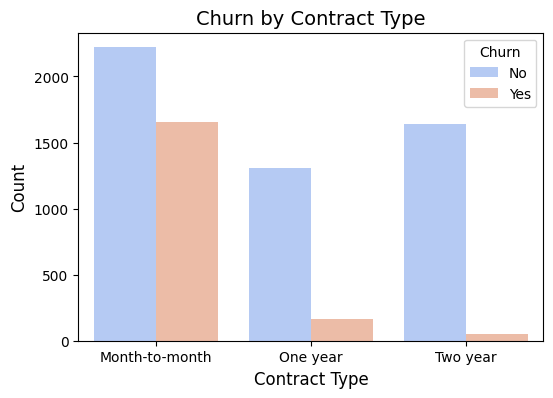

In [ ]:
# Churn by Contract Type :-
plt.figure(figsize=(6,4))

sns.countplot(x='Contract', hue='Churn', data=df, palette='coolwarm')

plt.title("Churn by Contract Type", fontsize=14)
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

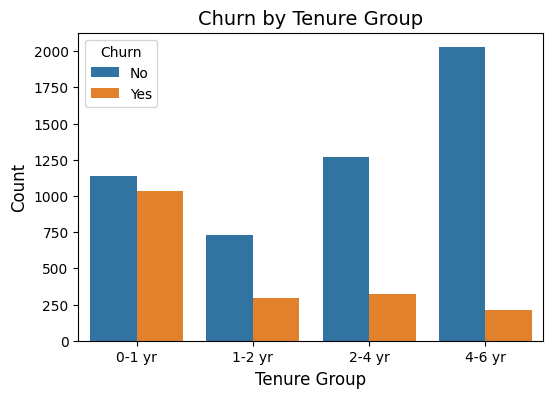

In [ ]:
# Churn by Tenure :-
# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                            labels=['0-1 yr','1-2 yr','2-4 yr','4-6 yr'])

plt.figure(figsize=(6,4))

sns.countplot(x='tenure_group', hue='Churn', data=df)

plt.title("Churn by Tenure Group", fontsize=14)
plt.xlabel("Tenure Group", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

# If Churn (Yes) bar is high → more customers are leaving ❌
# If Churn (No) bar is high → more customers are staying ✅


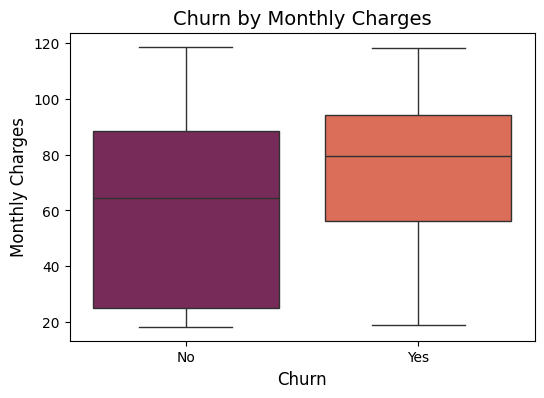

In [ ]:
# Churn by Monthly Charges :-
plt.figure(figsize=(6,4))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', palette='rocket', legend=False)

plt.title("Churn by Monthly Charges", fontsize=14)
plt.xlabel("Churn", fontsize=12)
plt.ylabel("Monthly Charges", fontsize=12)

plt.show()

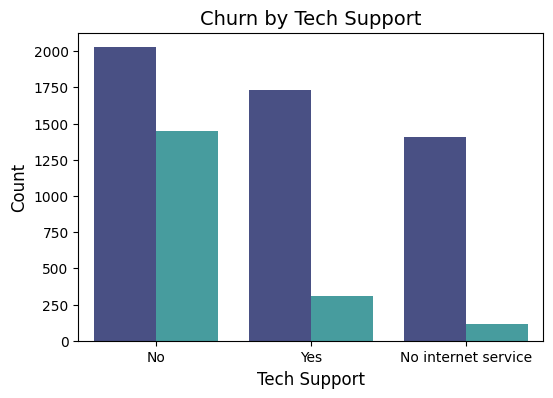

In [ ]:
# Churn by Services :-
plt.figure(figsize=(6,4))

sns.countplot(x='TechSupport', hue='Churn', data=df, palette='mako', legend=False)

plt.title("Churn by Tech Support", fontsize=14)
plt.xlabel("Tech Support", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

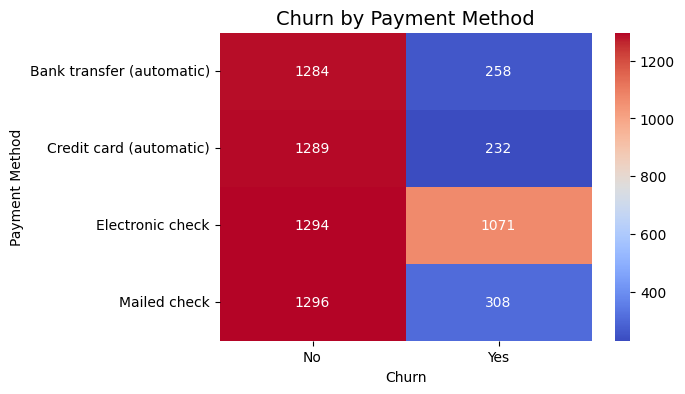

In [ ]:
# Churn by Payment Method
pivot = pd.crosstab(df['PaymentMethod'], df['Churn'])

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(pivot, annot=True, fmt='d', cmap='coolwarm')

plt.title("Churn by Payment Method", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Payment Method")

plt.show()